### Overview

Embeddings are a way to compress large amounts of information into a smaller set of features that represent meaningful semantics. Instead of raw pixel values, each location is represented by a dense vector that captures the semantic content of the landscape.

[TESSERA](https://github.com/ucam-eo/geotessera) is an open foundation model for Earth observation that learns such embeddings from satellite yearly time-series of Sentinel-1 and Sentinel-2 satellite imagery. The resulting embeddings are produced at 10m resolution have 128-dimensions. They represent the pixel's full annual history and can be directly used for downstream tasks. Here we use the precomputed embeddings as input features for supervised land cover classification with a set of labeled Ground Control Points (GCPs).

This notebook uses the [`geotessera`](https://geotessera.readthedocs.io/en/latest/index.html) package for querying and fetching the embeddings. 

> As of July 2026, effort is underway to release these embeddings in a standard cloud-native format, and [processing is underway](https://github.com/ucam-eo/geotessera/issues/303) for them to be released on Source Cooperative. This notebook will be updated to use the cloud-native embeddings once they are available.


### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
if environment in ['colab', 'colab_enterprise']:
    !pip install rioxarray scikit-learn geotessera

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import rioxarray as rxr
import tempfile
import xarray as xr
from geotessera import GeoTessera
from sklearn.neighbors import KNeighborsClassifier
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling


### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

aoi_gdf = gpd.read_file(aoi_filepath)
geometry = aoi_gdf.geometry.union_all()
geometry

### Load Training Data

The training data is a set of Ground Control Points (GCPs) — point features, each labeled with a land cover class. We load the GeoJSON file with GeoPandas.

In [ ]:
gcp_filepath = os.path.join(data_folder, 'gcps.geojson')

if not os.path.exists(gcp_filepath):
    print(f'GCP file not found at {gcp_filepath}. Using default GCPs.')
    gcp_filepath = (
        'https://storage.googleapis.com/spatialthoughts-public-data/'
        'python-remote-sensing/gcps.geojson'
    )

gcp_gdf = gpd.read_file(gcp_filepath)
gcp_gdf.head()

Let's check how many samples we have for each class.

In [ ]:
gcp_gdf['landcover'].value_counts(sort=False)

In [ ]:
class_colors = {
    0: '#cc6d8f', # Urban
    1: '#ffc107', # Bare
    2: '#1e88e5', # Water
    3: '#004d40', # Vegetation
}

class_names = {
    0: 'Urban',
    1: 'Bare',
    2: 'Water',
    3: 'Vegetation'
}

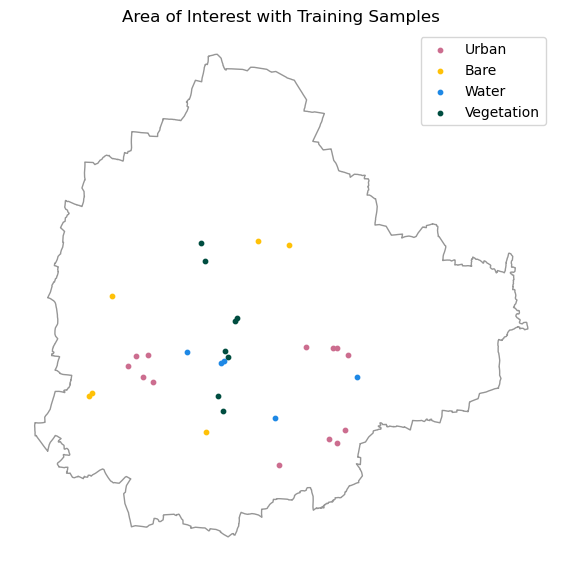

In [46]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7,7)
aoi_gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#969696')

# Plot the GCPs
for class_label, group in gcp_gdf.groupby('landcover'):
    group.plot(
        ax=ax,
        color=class_colors.get(class_label, 'red'),
        markersize=10,
        label=class_names.get(class_label, f'Unknown Class {class_label}')
    )

ax.legend(loc='upper right')
ax.set_title('Area of Interest with Training Samples')
ax.set_axis_off()
plt.show()

### Load TESSERA Embeddings

We take the bounding box of our area of interest in geographic coordinates (longitude/latitude). GeoTessera uses this to work out which embedding tiles cover the region.

In [ ]:
# (min_lon, min_lat, max_lon, max_lat) in EPSG:4326
bbox = geometry.bounds
bbox

We use the `geotessera` package to work with TESSERA embeddings. Rather than loading a full mosaic covering the whole AOI up front, embeddings are fetched only as needed — sparsely, at training points, and tile-by-tile when classifying.

We initialize a `GeoTessera` client and set the `embeddings_dir` to the `data_folder`. Any tile downloaded will be cached in that folder and whenever it is needed again - it is read back from the local cache instead of being re-downloaded.

In [ ]:
year = 2023
gt = GeoTessera(embeddings_dir=data_folder)

### Extract Embeddings at Training Samples

To extract embedding values at the training points, we use GeoTessera's own `sample_embeddings_at_points()` rather than fetching the full mosaic just to index a handful of scattered locations out of it. It groups the points by which tile they fall into and reads values directly from just those tiles.

In [ ]:
# Sample embeddings directly at the GCP locations. gcp_gdf is
# already in WGS84, which is what sample_embeddings_at_points()
# expects, so it can be passed straight in.
gcp_embeddings_arr = gt.sample_embeddings_at_points(gcp_gdf, year=year)  # (n_points, 128)
gcp_embeddings_arr

Wrap the sampled values in an `xarray.DataArray` with the `landcover` label attached to each point, so the rest of the notebook (training the classifier below) can use it consistently.

In [ ]:
gcp_embeddings = xr.DataArray(
    gcp_embeddings_arr.T,  # (128, n_points) -> dims ('band', 'gcp_id')
    dims=('band', 'gcp_id'),
    coords={
        'band': np.arange(gcp_embeddings_arr.shape[1]),
        'landcover': ('gcp_id', gcp_gdf['landcover'].values),
    },
    name='embeddings',
)
gcp_embeddings

### Train a Classifier

We use [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), a good choice for low-shot classification with a small number of labeled points.

In [ ]:
# Prepare the data for the classifier
X = gcp_embeddings.values.T # Transpose to have (n_samples, n_features)
y = gcp_embeddings['landcover'].values

# Initialize the KNeighborsClassifier
# Using n_neighbors=5 as a common starting point
classifier = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Train the classifier
classifier.fit(X, y)

### Classify the Image

We now run the model to predict the class tile by tile. For every TESSERA tile covering the AOI, we fetch its embeddings with `gt.fetch_embedding()`, classify it in batches to keep the kNN distance-matrix memory bounded, and write the result straight to disk. At any point in the loop only a single tile's embeddings are in memory.

In [ ]:
def classify_pixels(pixels, valid, classifier, batch_size=50_000):
    predicted = np.full(pixels.shape[0], np.nan, dtype=np.float32)
    valid_indices = np.where(valid)[0]
    for start in range(0, len(valid_indices), batch_size):
        batch_idx = valid_indices[start:start + batch_size]
        predicted[batch_idx] = classifier.predict(pixels[batch_idx]).astype(np.float32)
    return predicted


tiles_to_fetch = gt.registry.load_blocks_for_region(bbox, year)
print(f'{len(tiles_to_fetch)} tiles to classify')

with tempfile.TemporaryDirectory() as tile_dir:
    tile_paths = []

    for year_val, tile_lon, tile_lat in tiles_to_fetch:
        embedding, tile_crs, tile_transform = gt.fetch_embedding(tile_lon, tile_lat, year_val)
        h, w, bands = embedding.shape
        pixels = embedding.reshape(-1, bands)
        valid = ~np.isnan(pixels).any(axis=1)
        predicted = classify_pixels(pixels, valid, classifier).reshape(h, w)

        tile_path = os.path.join(tile_dir, f'tile_{tile_lon:.2f}_{tile_lat:.2f}.tif')
        tile_profile = {
            'driver': 'GTiff', 'height': h, 'width': w, 'count': 1,
            'dtype': 'float32', 'crs': tile_crs, 'transform': tile_transform,
            'nodata': np.nan, 'compress': 'deflate',
        }
        with rasterio.open(tile_path, 'w', **tile_profile) as dst:
            dst.write(predicted, 1)
        tile_paths.append(tile_path)
        del embedding, pixels, predicted

    print(f'Classified {len(tile_paths)} tiles')

    # Merge tiles into a mosaic. rasterio.merge() assumes every input shares
    # one CRS — it does not reproject. TESSERA tiles for a small AOI are
    # normally all in the same UTM zone, but if the AOI happened to straddle
    # a zone boundary, merging mismatched-CRS tiles directly would silently
    # misalign the mosaic. Before merging, we check each tile's CRS and
    # reproject only the ones that don't match the majority CRS.
    tile_crs_list = [rasterio.open(p).crs for p in tile_paths]
    target_crs = max(set(tile_crs_list), key=tile_crs_list.count)

    if len(set(tile_crs_list)) > 1:
        print(f'Tiles span {len(set(tile_crs_list))} distinct CRS; reprojecting outliers to {target_crs}')

    normalized_paths = []
    for path, crs in zip(tile_paths, tile_crs_list):
        if crs == target_crs:
            normalized_paths.append(path)
            continue
        reproj_path = path.replace('.tif', '_reproj.tif')
        with rasterio.open(path) as src:
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds)
            profile = src.profile.copy()
            profile.update(crs=target_crs, transform=transform, width=width, height=height)
            with rasterio.open(reproj_path, 'w', **profile) as dst:
                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=transform, dst_crs=target_crs,
                    resampling=Resampling.nearest)
        normalized_paths.append(reproj_path)

    src_files = [rasterio.open(p) for p in normalized_paths]
    mosaic, out_transform = merge(src_files)

    out_profile = src_files[0].profile.copy()
    out_profile.update({
        'height': mosaic.shape[1],
        'width': mosaic.shape[2],
        'transform': out_transform,
    })

    raw_output_path = os.path.join(output_folder, 'classification_embeddings.tif')
    with rasterio.open(raw_output_path, 'w', **out_profile) as dst:
        dst.write(mosaic)

    for src in src_files:
        src.close()

print(f'Wrote {raw_output_path}')


### Visualize the Classification

Read the classified image and visualze it.

In [ ]:
classified = rxr.open_rasterio(raw_output_path)
classified = classified.squeeze('band', drop=True)
classified.name = 'landcover'
classified

In [44]:
aoi_gdf_reprojected = aoi_gdf.to_crs(classified.rio.crs)
classified_clipped = classified.rio.clip(aoi_gdf_reprojected.geometry)

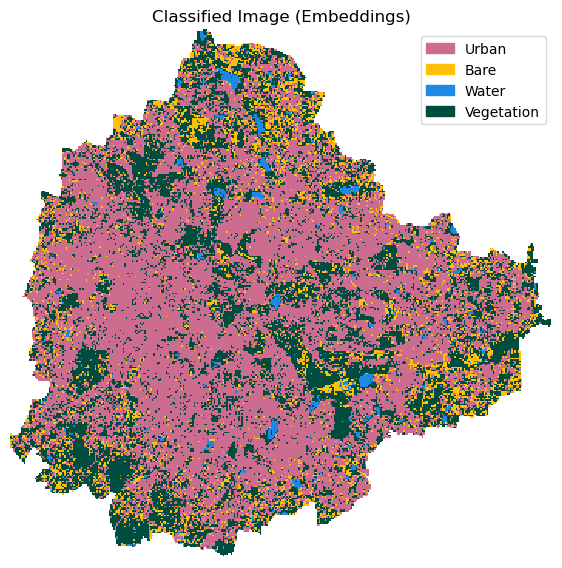

In [45]:
sorted_labels = sorted(class_colors.keys())
cmap = mcolors.ListedColormap([class_colors[c] for c in sorted_labels])
cmap.set_bad(alpha=0)
norm = mcolors.BoundaryNorm(
    [i - 0.5 for i in range(len(sorted_labels) + 1)], cmap.N)

preview = classified_clipped.rio.reproject(
    classified_clipped.rio.crs, resolution=100)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7, 7)
preview.plot.imshow(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
ax.legend(
    handles=[mpatches.Patch(
        color=class_colors[c],
        label=class_names[c]) for c in sorted_labels],
    loc='upper right'
)
ax.set_title('Classified Image (Embeddings)')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Save Classified Image

Save the result as a Cloud-Optimized GeoTIFF to the configured output folder.

In [ ]:
def write_cog_with_colormap(data_array, output_path, color_table):
    if data_array.dtype != np.dtype('uint8'):
        raise TypeError(f'data_array must be uint8 for a color table to attach')

    # Write to a temp file, add color table, then convert to COG
    tmp_path = output_path + '.tmp.tif'
    data_array.rio.to_raster(tmp_path)

    with rasterio.open(tmp_path) as src:
        profile = src.profile.copy()
        profile['driver'] = 'COG'
        data = src.read(1)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
            dst.write_colormap(1, color_table)

    os.remove(tmp_path)

In [ ]:
# Build rasterio color table from the class_colors hex dict
color_table = {
    label: tuple(int(c * 255) for c in mcolors.to_rgb(hex_color))
    for label, hex_color in class_colors.items()
}

# Set no-data
classified_clipped = classified_clipped.fillna(255).astype(np.uint8) \
    .rio.write_nodata(255)

output_file = f'classification_embeddings_tessera.tif'
output_path = os.path.join(output_folder, output_file)
write_cog_with_colormap(classified_clipped, output_path, color_table)
print(f'Wrote {output_path}')